# 1. Import Required Libraries

* **Docling**: Used to convert PDF documents into structured **Markdown** and high-quality **page images**.
* **Groq & Google Generative AI**: Replacements for OpenAI to handle lightning-fast text extraction and advanced **multimodal (Vision)** analysis.
* **Pydantic**: Used to declare **structured data models (Schemas)**. This ensures the AI returns data in a specific JSON format that is easy to validate and consume.
* **Secure Auth**: Using `getpass` to handle **API keys** securely without exposing them in the code.

In [1]:
# --- 1. Docling (PDF Conversion) ---
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

# --- 2. AI Platforms (Groq & Gemini) ---
import groq
import google.generativeai as genai

# --- 3. Structured Data & Validation (Pydantic) ---
from pydantic import BaseModel, Field
from typing import List, Optional
from datetime import datetime

# --- 4. Utilities ---
import getpass
import json
from PIL import Image

print("✅ Libraries imported successfully (Optimized for Groq & Gemini)")

c:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported successfully (Optimized for Groq & Gemini)


C:\Users\ADmiN\AppData\Local\Temp\ipykernel_10604\2560802783.py:8: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
# Define PDF conversion options
pipeline_options = PdfPipelineOptions()
pipeline_options.images_scale = 2
pipeline_options.generate_page_images = True

# Initialize the converter with format options
doc_converter = DocumentConverter(
    format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)}
)

# 3. Load PDF Document

Specify the path to the PDF invoice to extract. Use the configured `DocumentConverter` to convert the file into a structured `document` containing both text and page images.
The converted document is used for subsequent text and image-based extraction steps, now with structured outputs

In [3]:
# Specify the path to your PDF file
pdf_path = "./docs/pdf_invoice.pdf"
result = doc_converter.convert(pdf_path)

[INFO] 2026-03-24 11:18:29,605 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-24 11:18:29,646 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-24 11:18:29,649 [RapidOCR] main.py:53: Using C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-24 11:18:29,976 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-24 11:18:29,985 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-24 11:18:29,985 [RapidOCR] main.py:53: Using C:\Users\ADmiN\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-24 11:18:30,175 [RapidOCR] base.py:

# 4. Setup Groq, Gemini & Extraction Helpers

* **Markdown Extraction**: Export the converted document into **Markdown format** for fast text analysis using **Groq**.
* **API Configuration**: Securely collect API keys for **Groq** (Text) and **Gemini** (Vision).
* **Smart Helpers**: Define functions that handle both **structured text extraction** and **multimodal image analysis**, ensuring the model returns data that matches our Pydantic schemas.

In [9]:
# 1. Access the document object
doc = result.document

# 2. Export to markdown format (Returns string in recent Docling versions)
document_markdown = doc.export_to_markdown()

# 3. Verify the extraction
if document_markdown:
    print("✅ Markdown Text Extracted Successfully!")
    print("-" * 30)
    print(document_markdown[:300] + "...") # Show a snippet
else:
    print("❌ Failed to extract markdown text.")

✅ Markdown Text Extracted Successfully!
------------------------------
<!-- image -->

## INVOICE

# 16384

Bill To:

Adam Hart

Ship To:

Nottingham, England, United Kingdom

Dec 08 2012

Standard Class

$6,208.84

Date:

Ship Mode:

Balance Due:

| Item                              | Quantity   | Rate      | Amount    |
|-----------------------------------|----------...


In [10]:
# 2. Setup API Keys securely
groq_key = getpass.getpass("Enter Groq API Key: ")
groq_client = groq.Groq(api_key=groq_key)

gemini_key = getpass.getpass("Enter Gemini API Key: ")
genai.configure(api_key=gemini_key)

In [11]:
# 3. Define the Extraction Helpers

# Helper 1: Fast text extraction with Groq
def ask_groq_text(user_content):
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant", 
        messages=[{"role": "user", "content": user_content}]
    )
    return response.choices[0].message.content

# Helper 2: Smart vision extraction with Gemini (Auto-selects working model)
def ask_gemini_vision(image_pil, prompt):
    available_models = [m.name for m in genai.list_models() if 'generateContent' in m.supported_generation_methods]
    chosen_model_name = next((m for m in available_models if 'flash' in m), available_models[0])
    
    model = genai.GenerativeModel(model_name=chosen_model_name)
    response = model.generate_content([prompt, image_pil])
    return response.text

print("✅ Markdown extracted and Helpers are ready!")

✅ Markdown extracted and Helpers are ready!


# 5. Define Pydantic Models for Structured Outputs

In this section, we define **Pydantic models** to enforce a strict schema on the AI's response. By using these models, we ensure that:
* **Data Consistency**: The model returns exactly the fields we need (e.g., `invoice_number`, `balance_due`).
* **Type Validation**: Numbers are treated as `float` and dates as `str` for reliability.
* **Auto-Documentation**: We use `Field(description=...)` to provide the LLM with clear instructions on what each attribute represents.

In [13]:
from pydantic import BaseModel, Field
from typing import Optional

# 1. Model for Invoice Number (Best for Groq/Text)
class InvoiceNumber(BaseModel):
    invoice_number: str = Field(description="The unique alphanumeric identifier of the invoice")

# 2. Model for Balance Due (Numeric extraction)
class BalanceDue(BaseModel):
    balance_due: float = Field(description="The total outstanding balance as a decimal number")

# 3. Model for Invoice Date (Best for Gemini/Vision)
class InvoiceDate(BaseModel):
    invoice_date: str = Field(description="The date the invoice was issued (e.g., 'Dec 08 2012')")

# 4. Model for Shipping Address (Structured location data)
class ShippingAddress(BaseModel):
    street: Optional[str] = Field(None, description="Street name and house number")
    city: Optional[str] = Field(None, description="City or Town")
    state: Optional[str] = Field(None, description="State, Province, or Region")
    zip_code: Optional[str] = Field(None, description="Postal or Zip code")
    country: Optional[str] = Field(None, description="Full country name")

print("✅ Pydantic Models defined successfully!")

✅ Pydantic Models defined successfully!


# 6. Extract Attributes Using Document Text (Markdown)

We use the **Markdown text** extracted earlier as input for **Groq (Llama 3)**. Instead of a conversation, we force the model to return a **pure JSON object** that matches our Pydantic models (`InvoiceNumber` and `BalanceDue`). 
This ensures the output is structured and ready for database entry or further processing.

In [27]:
# --- Helper function for Structured Text Extraction (Groq) ---
def ask_groq_structured(prompt, pydantic_model, text_content):
    # We add strict instructions to the prompt to get JSON
    full_prompt = f"""
    Context: {text_content}
    Question: {prompt}
    
    Return ONLY a JSON object that matches this schema: {pydantic_model.model_json_schema()}
    Do not include any explanations or extra text.
    """
    
    raw_response = ask_groq_text(full_prompt)
    
    # Clean the response (sometimes AI adds markdown code blocks ```json ... ```)
    clean_json = raw_response.replace("```json", "").replace("```", "").strip()
    
    # Parse JSON and convert to Pydantic object
    data = json.loads(clean_json)
    return pydantic_model(**data)

In [25]:
# --- Execution ---

# 1. Extract Invoice Number
question_1 = "What is the invoice number?"
answer_1 = ask_groq_structured(question_1, InvoiceNumber, document_markdown)
print(f"✅ Invoice Number: {answer_1.invoice_number}")

✅ Invoice Number: 16384


In [28]:
# 2. Extract Balance Due
question_2 = "What is the total balance due?"
answer_2 = ask_groq_structured(question_2, BalanceDue, document_markdown)
print(f"✅ Balance Due: ${answer_2.balance_due}")

✅ Balance Due: $6208.84


# 7. Extract Attributes Using Page Images (Multimodal)

In this final step, we use **Gemini Vision** to extract information that is visually structured, such as:
1. **Invoice Date**: Often located in specific corners.
2. **Shipping Address**: Usually formatted in blocks that vision models understand better than raw text.

By passing the image directly to Gemini and specifying our **Pydantic models**, we ensure the output is structured and validated.

In [35]:

# --- Helper function for Structured Vision Extraction (Gemini) ---
def ask_gemini_structured(prompt, pydantic_model, image_pil):
    # We ask Gemini to return JSON based on the model schema
    full_prompt = f"""
    {prompt}
    
    Return ONLY a JSON object that matches this schema:
    {pydantic_model.model_json_schema()}
    Do not include any text other than the JSON object.
    """
    
    # Use the helper we defined earlier
    raw_response = ask_gemini_vision(image_pil, full_prompt)
    
    try:
        # Extract JSON from the response
        json_match = re.search(r'\{.*\}', raw_response, re.DOTALL)
        if json_match:
            data = json.loads(json_match.group(0))
            return pydantic_model(**data)
    except Exception as e:
        print(f"❌ Error parsing Gemini response: {e}")
        print(f"Raw response: {raw_response}")
        return None

In [36]:
# --- Execution ---

# 1. Access the first page image correctly
# In your version, 'image' is already the PIL object
page_image = result.pages[0].image 

In [37]:
# 2. Extract Invoice Date
question_3 = "Extract the invoice date from the image."
answer_3 = ask_gemini_structured(question_3, InvoiceDate, page_image)
if answer_3:
    print(f"✅ Invoice Date: {answer_3.invoice_date}")

✅ Invoice Date: Dec 08 2012


In [38]:
# 3. Extract Shipping Address
question_4 = "Extract the shipping address from the image."
answer_4 = ask_gemini_structured(question_4, ShippingAddress, page_image)
if answer_4:
    print(f"✅ Shipping Address: {answer_4}")

✅ Shipping Address: street=None city='Nottingham' state='England' zip_code=None country='United Kingdom'


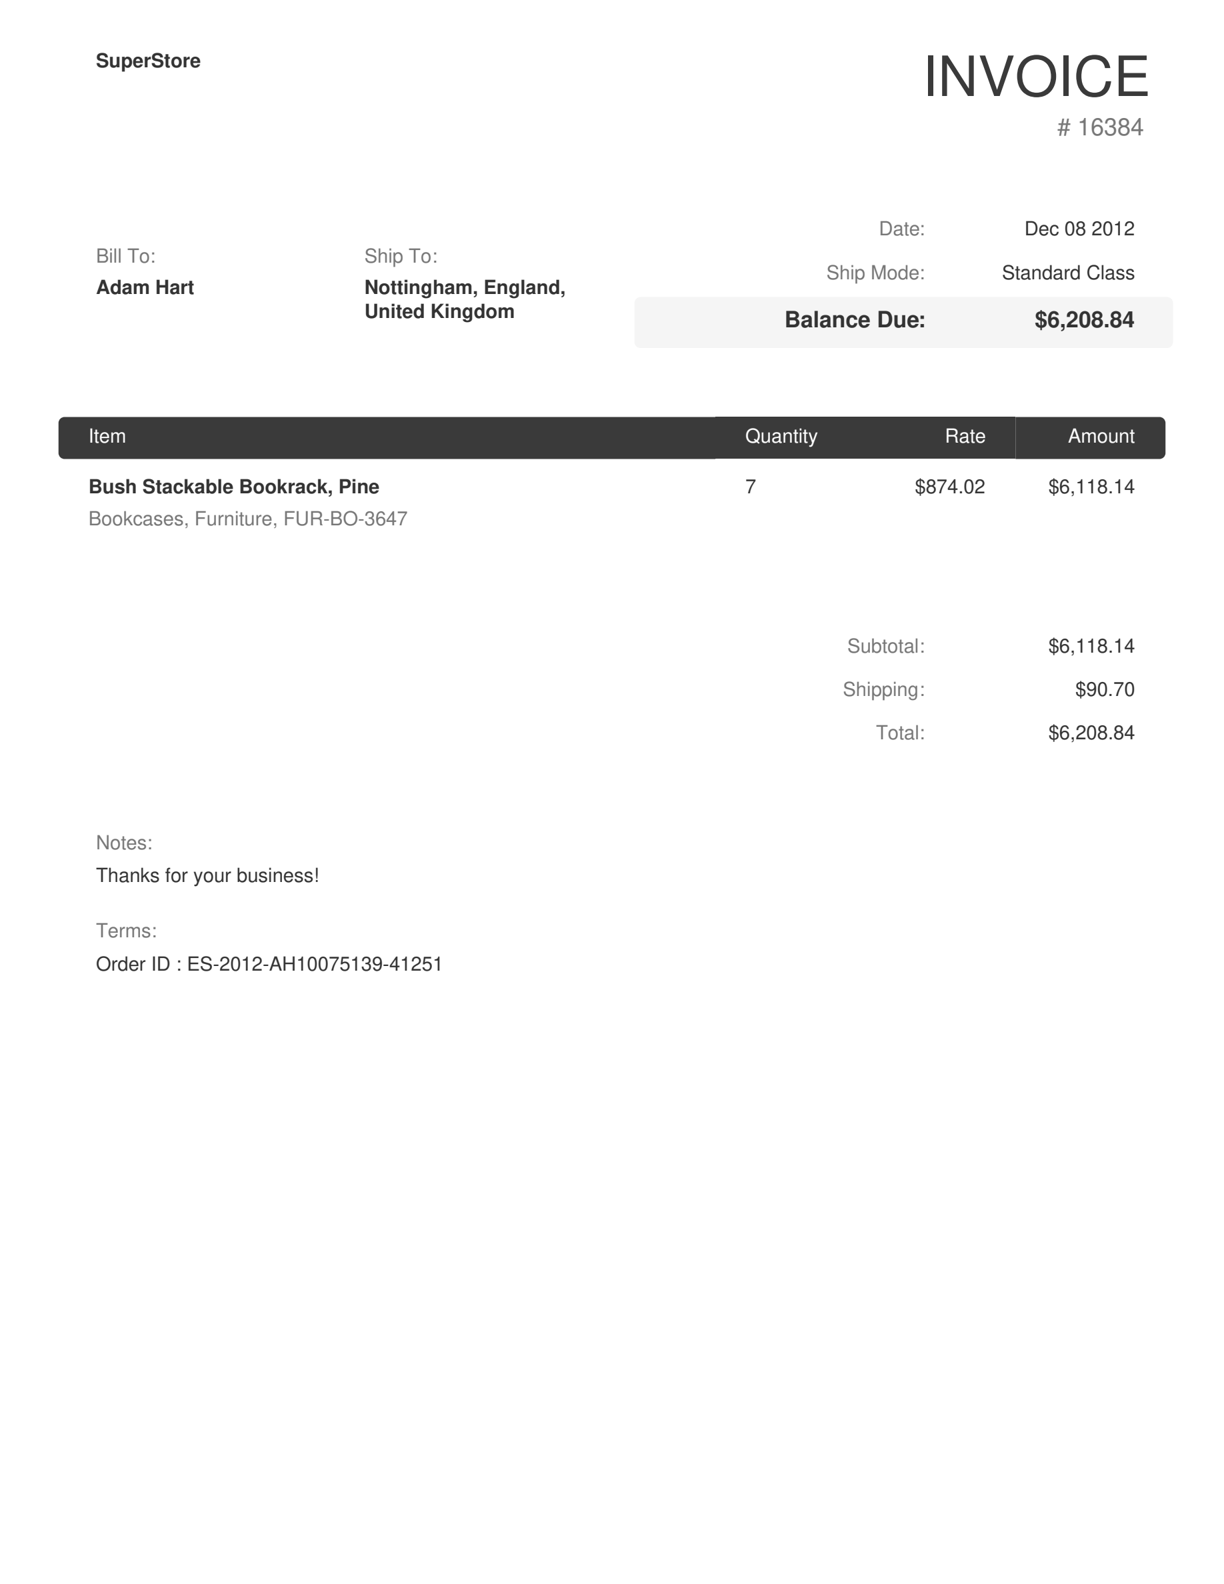

In [39]:
display(result.pages[0].image)

# 8. Key Considerations for Open & Multimodal Models

When building AI extraction systems for production, enforcing **Structured Outputs** is non-negotiable. Here’s what we've learned using Groq and Gemini:

* **Pydantic Validation**: Even when models (like Llama 3 on Groq) don't support `response_format` natively like OpenAI, we can still enforce structure by parsing their JSON output into Pydantic models. This guarantees data integrity.
* **Model Specialization**: 
    * **Groq (Llama 3)**: Best for ultra-fast text-based extraction from Markdown.
    * **Gemini (Vision)**: Best for complex layouts where spatial positioning (like addresses or stamps) matters.
* **Error Handling**: Always implement JSON cleaning (using Regex) when working with Open Source models, as they might include conversational filler around the JSON object.
* **Native Multimodal**: Using Gemini allows for direct PIL image processing, removing the overhead of Base64 encoding and simplifying the pipeline.